In [1]:
!pip install unsloth

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.3/52.3 kB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 2.4 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of torchvision to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 313.5/313.5 kB 8.6 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 561.5/561.5 kB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 544.8/544.8 kB 33.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 93.0 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.3/197.3 kB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.2/117.2 MB 14.3 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 888.1/888.1 MB 1.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.5/155.5 MB 2.0 MB/s eta 0:00:00:00:0100:01
 

In [ ]:
from unsloth import FastLanguageModel
import torch
max_seq_length = 2048 # Choose any! We auto support RoPE Scaling internally!
dtype = None # None for auto detection. Float16 for Tesla T4, V100, Bfloat16 for Ampere+
load_in_4bit = True # Use 4bit quantization to reduce memory usage. Can be False.

# 4bit pre quantized models we support for 4x faster downloading + no OOMs.
fourbit_models = [
    "unsloth/Meta-Llama-3.1-8B-bnb-4bit",      # Llama-3.1 15 trillion tokens model 2x faster!
    "unsloth/Meta-Llama-3.1-8B-Instruct-bnb-4bit",
    "unsloth/Meta-Llama-3.1-70B-bnb-4bit",
    "unsloth/Meta-Llama-3.1-405B-bnb-4bit",    # We also uploaded 4bit for 405b!
    "unsloth/Mistral-Nemo-Base-2407-bnb-4bit", # New Mistral 12b 2x faster!
    "unsloth/Mistral-Nemo-Instruct-2407-bnb-4bit",
    "unsloth/mistral-7b-v0.3-bnb-4bit",        # Mistral v3 2x faster!
    "unsloth/mistral-7b-instruct-v0.3-bnb-4bit",
    "unsloth/Phi-3.5-mini-instruct",           # Phi-3.5 2x faster!
    "unsloth/Phi-3-medium-4k-instruct",
    "unsloth/gemma-2-9b-bnb-4bit",
    "unsloth/gemma-2-27b-bnb-4bit",            # Gemma 2x faster!
] # More models at https://huggingface.co/unsloth

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "unsloth/Meta-Llama-3.1-8B-bnb-4bit",
    max_seq_length = max_seq_length,
    dtype = dtype,
    load_in_4bit = load_in_4bit,
    # token = "hf_...", # use one if using gated models like meta-llama/Llama-2-7b-hf
)

# Prompt Format

In [4]:
alpaca_prompt = """Below is an instruction that describes a task, paired with an input that provides further context. Write a response that appropriately completes the request.

### Instruction:
You are an IELTS Writing Task 2 examiner. Evaluate the essay using IELTS band descriptors. 
Internally calculate scores for the four criteria, average them, and round to the nearest 0.5.
Return ONLY the overall band score in strict JSON format.

### Input:
Essay prompt: {}
Essay: {}

### Response:
{}"""

# 1. Preprocess

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("/kaggle/input/llm-final-project/train_final.csv")

In [3]:
print(df.describe())

           TR_Band      CC_Band      LR_Band     GRA_Band  Overall_Band  error
count  9833.000000  9833.000000  9833.000000  9833.000000   9833.000000    0.0
mean      6.088071     6.258263     5.962067     5.894030      6.112580    NaN
std       1.469663     1.514169     1.407305     1.407006      1.425723    NaN
min       1.000000     2.000000     2.000000     2.000000      2.000000    NaN
25%       5.000000     5.000000     5.000000     5.000000      5.000000    NaN
50%       6.000000     6.000000     6.000000     6.000000      6.000000    NaN
75%       7.000000     7.000000     7.000000     7.000000      7.000000    NaN
max       9.000000     9.000000     9.000000     9.000000      9.000000    NaN


/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


In [4]:
import pandas as pd
import numpy as np

def preprocess_band(df, col="band"):
    """
    Tiền xử lý cột band:
    - Trim khoảng trắng
    - Chuyển tất cả về string
    - Nếu giá trị số < 4 thì gán "<4"
    - Giữ nguyên số thập phân (vd: 6.5, 7.5)
    - Ép thành category có thứ tự hợp lý
    """
    def normalize_value(x):
        x = str(x).strip()
        try:
            val = float(x)
            if val < 4:
                return "<4"
            else:
                return str(val)   # giữ thập phân
        except ValueError:
            return x

    # Chuẩn hóa giá trị
    df[col] = df[col].apply(normalize_value)

    # Tạo list các band chuẩn theo thứ tự
    bands = ["<4"]
    # sinh từ 4.0 đến 9.0, thêm cả .5
    for b in np.arange(4.0, 9.5, 0.5):
        bands.append(str(b))

    # Ép thành category với thứ tự đã định nghĩa
    df[col] = pd.Categorical(df[col], categories=bands, ordered=True)

    return df

In [5]:
preprocess_band(df)

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,band,prompt,essay,TR_Band,TR_Comment,CC_Band,CC_Comment,LR_Band,LR_Mistakes,LR_Corrections,LR_Comment,GRA_Band,GRA_Mistakes,GRA_Corrections,GRA_Comment,Overall_Band,General_Feedback,error
0,7.5,Interviews form the basic criteria for most la...,It is believed by some experts that the tradit...,8.0,The essay sufficiently addresses all parts of ...,8.0,The essay is logically structured and the info...,7.0,exams writing; his teamwork skill is measured;...,written exams; their teamwork skills are measu...,The essay demonstrates a sufficient range of v...,7.0,...his ability to do the work and their proble...,...their ability to do the work and their prob...,"A variety of complex structures is used, and t...",7.5,This is a strong response with a very clear st...,NaN
1,5.0,Interviews form the basic selecting criteria f...,Nowadays numerous huge firms allocate an inter...,5.0,The essay addresses the task only partially. I...,5.0,"The essay is presented with some organization,...",5.0,choosing criteria; up-to-the-minute; reap the ...,selection criterion/criteria; effective/reliab...,The writer attempts to use some less common vo...,5.0,having excellent interpersonal skills are; mak...,having excellent interpersonal skills is; effe...,The essay shows a limited range of sentence st...,5.0,The essay presents a clear position and follow...,NaN
2,5.5,Interview form the basic selection criteria fo...,The interview section is the most vital part o...,6.0,"You have addressed all parts of the question, ...",6.0,The essay has a clear structure with an introd...,5.0,Interview section; prospect for the specified ...,The interview stage; prospective candidate for...,You have used an adequate range of vocabulary ...,5.0,Interview form the basic selection criteria; w...,Interviews form the basic selection criteria; ...,You have attempted to use a mix of simple and ...,5.5,Your essay presents a clear opinion and is log...,NaN
3,5.5,Interviews form the basic selection criteria f...,It is argued that the best method to recruit e...,6.0,The essay addresses the prompt by discussing b...,5.5,"The essay is organized into paragraphs, and th...",5.0,acquired by the recruiter; choosing the best e...,possessed by the applicant; choosing the best ...,The range of vocabulary is limited but minimal...,5.0,who do not lacks in any single question; accor...,who do not lack an answer to any single questi...,The writer attempts to use a mix of simple and...,5.5,Your essay has a clear structure and you prese...,NaN
4,4.0,Interviews from the basic selecting criteria f...,Nowadays many companies conduct interviews bef...,4.0,The response addresses the task only in a mini...,4.0,"The essay presents information and ideas, but ...",4.0,chosing; intetviuvs; campaigns; sending them; ...,choosing; interviews; companies; hiring them; ...,The writer uses only basic and repetitive voca...,4.0,Interviews from the basic selecting criteria; ...,Interviews form the basic selection criteria; ...,Only a very limited range of sentence structur...,4.0,"Your essay attempts to address the prompt, but...",NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9828,8.0,Some universities offer online courses as an a...,In today's most developing and rapid-growing w...,8.0,The response fully and appropriately addresses...,8.0,The essay demonstrates skillful organization o...,8.0,some studies filed needs a certain level of la...,some fields of study need a certain level of l...,The writer utilizes a wide and flexible range ...,8.0,another side some thinks student have to atten...,"on the other hand, some think students have to...",A wide range of grammatical structures is used...,8.0,This is a well-developed and persuasive essay ...,NaN
9829,4.5,Some people think that the main purpose of sch...,Some people think that the main purpose of sch...,4.0,"The essay attempts to address the prompt, but ...",5.0,There is a basic paragraph structure with an i...,4.0,make off spring

['7.5', '5.0', '5.5', '4.0', '<4', ..., '8.0', '7.0', '6.0', '8.5', '9.0']
Length: 12
Categories (12, object): ['<4' < '4.0' < '4.5' < '5.0' ... '7.5' < '8.0' < '8.5' < '9.0']
category


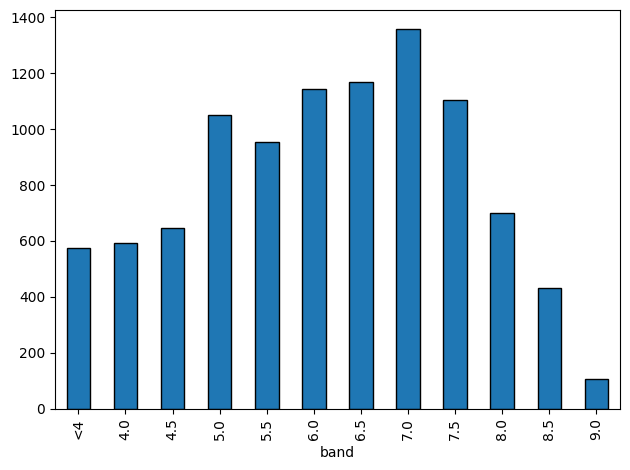

In [10]:
import matplotlib.pyplot as plt

print(df['band'].unique())
print(df['band'].dtype)

fig, ax = plt.subplots()

# Vẽ phân bố
df['band'].value_counts().sort_index().plot(
    kind="bar", edgecolor="black", ax=ax
)

# Căn chỉnh layout để không bị cắt nhãn
plt.tight_layout()

# Xuất file SVG
plt.savefig("band_distribution.png", format="png")

In [12]:
first_row = df.iloc[0]
print(first_row["prompt"])
print(first_row["essay"])

Interviews form the basic criteria for most large companies. However, some people think that the interview is not a reliable method of choosing whom to employ and there are other better methods. To what extent do you agree or disagree?
It is believed by some experts that the traditional approach of recruiting candidates which is interviewing is the best way, whereas others think different methods such as exams writing, CVs, cover letters or application letters and many more are good. I strongly agree with the statement, "interview is the most reliable approach to recruit workers" because this method assists the recruiters to know the person and his ability to do the work and their problem-solving abilities. 

To begin with, an interview enables the  recruiter to know the kind of person he or she is recruiting. It helps the employer to see the personality traits of the employee such as how he answers questions, his facial mannerisms and also his communication skills, that is, whether in

In [ ]:
# alpaca_prompt = Copied from above
FastLanguageModel.for_inference(model) # Enable native 2x faster inference
inputs = tokenizer(
[
    alpaca_prompt.format(
        first_row["prompt"], # prompt
        first_row["essay"], # essay
        "", # output - leave this blank for generation!
    )
], return_tensors = "pt").to("cuda")

from transformers import TextStreamer
text_streamer = TextStreamer(tokenizer)
_ = model.generate(**inputs, streamer = text_streamer, max_new_tokens = 256)

# 2. Fine-tune

In [ ]:
model = FastLanguageModel.get_peft_model(
    model,
    r = 16, # Choose any number > 0 ! Suggested 8, 16, 32, 64, 128
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj",
                      "gate_proj", "up_proj", "down_proj",],
    lora_alpha = 16,
    lora_dropout = 0, # Supports any, but = 0 is optimized
    bias = "none",    # Supports any, but = "none" is optimized
    use_gradient_checkpointing = True,
    random_state = 3407,
    use_rslora = False,  # We support rank stabilized LoRA
    loftq_config = None, # And LoftQ
)

In [ ]:
import json

EOS_TOKEN = tokenizer.eos_token # Must add EOS_TOKEN

def format_band_to_json(band_value):
    return json.dumps({"overallScore": band_value})

def formatting_prompts_func(examples):
    prompts = examples["prompt"]
    essays       = examples["essay"]
    outputs      = examples["band"]
    texts = []
    for prompt, essay, output in zip(prompts, essays, outputs):
        output_json = format_band_to_json(output)
        # Must add EOS_TOKEN, otherwise your generation will go on forever!
        text = alpaca_prompt.format(prompt, essay, output_json) + EOS_TOKEN
        texts.append(text)
    return { "text" : texts, }
pass

In [ ]:
from datasets import Dataset

dataset = Dataset.from_pandas(df)

In [ ]:
dataset = dataset.map(
    formatting_prompts_func,
    batched=True,
)

In [ ]:
print(dataset[0]["text"])  # in thử dòng đầu

In [ ]:
dataset = dataset.train_test_split(test_size=0.1, seed=42)

train_dataset = dataset["train"]
eval_dataset  = dataset["test"]

In [ ]:
from trl import SFTTrainer
from transformers import TrainingArguments
from unsloth import is_bfloat16_supported

trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    train_dataset = train_dataset,
    eval_dataset= eval_dataset,
    dataset_text_field = "text",
    max_seq_length = max_seq_length,
    dataset_num_proc = 2,
    packing = False, # Can make training 5x faster for short sequences.
    args = TrainingArguments(
        per_device_train_batch_size = 2,
        gradient_accumulation_steps = 4,
        warmup_steps = 5,
        num_train_epochs = 3, # Set this for full training run.
        #max_steps = 8,
        learning_rate = 2e-4,
        fp16 = not is_bfloat16_supported(),
        bf16 = is_bfloat16_supported(),
        logging_steps = 1,
        optim = "adamw_8bit",
        weight_decay = 0.01,
        lr_scheduler_type = "linear",
        seed = 3407,
        output_dir = "/kaggle/working/",
        report_to = "none", # Use this for WandB etc,
        eval_strategy = "steps",
        eval_steps = 500                  # bao lâu thì đánh giá 1 lần
        
    ),
)

In [ ]:
train_from_checkpoint = False
checkpoint_path = "/kaggle/input/llm_final_band_only/tensorrtllm/default/1/checkpoint-1500"

In [ ]:
if train_from_checkpoint:
    # Resume từ checkpoint
    trainer.train(resume_from_checkpoint = checkpoint_path)
else:
    trainer_stats = trainer.train()

In [ ]:
output_dir = "/kaggle/working/Llama_8b_Band_Only_model"

model.save_pretrained(output_dir)  # Local saving
tokenizer.save_pretrained(output_dir)
print(f"Model saved to {output_dir}")

In [ ]:
import zipfile
import os

def zip_folder(folder_path, output_path):
    with zipfile.ZipFile(output_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
        for root, dirs, files in os.walk(folder_path):
            for file in files:
                file_path = os.path.join(root, file)
                arcname = os.path.relpath(file_path, start=folder_path)
                zipf.write(file_path, arcname)

zip_folder(output_dir, 'Llama_8b_Band_Only_model.zip')
print(f"Zip Model saved to Llama_8b_Band_Only_model.zip")